# 04 - Feature Engineering


**Outputs**:
- `features.parquet` -- monthly decision-point features
- `feature_summary.csv` -- feature descriptions and statistics

**Universe**: 10 tickers (AAPL, AMZN, AVGO, GOOG, GOOGL, META, MSFT, NVDA, TSLA, WMT)  


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PROCESSED = Path('../data/processed')
OUTPUT_DIR = PROCESSED  # Save outputs to same folder

# Full NASDAQ top 10 universe
UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']

print(f"Universe: {UNIVERSE}")
print(f"Data directory: {PROCESSED}")

Universe: ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']
Data directory: ../data/processed


## 1. Load Cleaned Data

In [2]:
# Load cleaned data from 02_data_cleaning.ipynb
daily = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
income = pd.read_parquet(PROCESSED / 'income_clean.parquet')
balance = pd.read_parquet(PROCESSED / 'balance_clean.parquet')
cashflow = pd.read_parquet(PROCESSED / 'cashflow_clean.parquet')
overview = pd.read_parquet(PROCESSED / 'overview_clean.parquet')

# Filter to universe
daily = daily[daily['symbol'].isin(UNIVERSE)].copy()
income = income[income['symbol'].isin(UNIVERSE)].copy()
balance = balance[balance['symbol'].isin(UNIVERSE)].copy()
cashflow = cashflow[cashflow['symbol'].isin(UNIVERSE)].copy()
overview = overview[overview['symbol'].isin(UNIVERSE)].copy()

print(f"Daily prices: {daily.shape}")
print(f"Income statements: {income.shape}")
print(f"Balance sheets: {balance.shape}")
print(f"Cash flow: {cashflow.shape}")
print(f"Overview: {overview.shape}")

Daily prices: (52486, 10)
Income statements: (781, 27)
Balance sheets: (773, 39)
Cash flow: (778, 31)
Overview: (10, 8)


In [3]:
# Parse dates
daily['date'] = pd.to_datetime(daily['date'])
income['fiscalDateEnding'] = pd.to_datetime(income['fiscalDateEnding'])
balance['fiscalDateEnding'] = pd.to_datetime(balance['fiscalDateEnding'])
cashflow['fiscalDateEnding'] = pd.to_datetime(cashflow['fiscalDateEnding'])

# Sort
daily = daily.sort_values(['symbol', 'date']).reset_index(drop=True)
income = income.sort_values(['symbol', 'fiscalDateEnding']).reset_index(drop=True)
balance = balance.sort_values(['symbol', 'fiscalDateEnding']).reset_index(drop=True)
cashflow = cashflow.sort_values(['symbol', 'fiscalDateEnding']).reset_index(drop=True)

print(f"Date range: {daily['date'].min()} to {daily['date'].max()}")

Date range: 2000-01-03 00:00:00 to 2025-12-31 00:00:00


## 2. Create Monthly Decision Points

Covered calls are typically sold monthly. We create decision points at the last trading day of each month.

In [4]:
# Get last trading day of each month per ticker
daily['year_month'] = daily['date'].dt.to_period('M')
monthly = daily.groupby(['symbol', 'year_month']).last().reset_index()
monthly['decision_date'] = monthly['date']

print(f"Monthly decision points: {len(monthly)}")
print(f"Per ticker: ~{len(monthly) // len(UNIVERSE)} months")
monthly[['symbol', 'decision_date', 'adjusted_close']].head(10)

Monthly decision points: 2507
Per ticker: ~250 months


,symbol,decision_date,adjusted_close
0,AAPL,2000-01-31,0.777142
1,AAPL,2000-02-29,0.858564
2,AAPL,2000-03-31,1.017288
3,AAPL,2000-04-28,0.929275
4,AAPL,2000-05-31,0.629204
5,AAPL,2000-06-30,0.784708
6,AAPL,2000-07-31,0.761187
7,AAPL,2000-08-31,0.912945
8,AAPL,2000-09-29,0.385762
9,AAPL,2000-10-31,0.293029


## 3. Technical Features (Price-Based)

Features computed from daily price data, then sampled at monthly decision points.

In [5]:
def compute_technical_features(df):
    """
    Compute technical features for a single ticker.
    Input: daily price dataframe sorted by date
    Output: dataframe with technical features
    """
    df = df.copy().sort_values('date')
    
    # Daily returns
    df['daily_return'] = df['adjusted_close'].pct_change()
    
    # Realized volatility (annualized)
    df['vol_10d'] = df['daily_return'].rolling(10).std() * np.sqrt(252)
    df['vol_21d'] = df['daily_return'].rolling(21).std() * np.sqrt(252)
    df['vol_63d'] = df['daily_return'].rolling(63).std() * np.sqrt(252)
    
    # Momentum
    df['mom_5d'] = df['adjusted_close'].pct_change(5)
    df['mom_21d'] = df['adjusted_close'].pct_change(21)
    df['mom_63d'] = df['adjusted_close'].pct_change(63)
    
    # Moving averages
    df['sma_21d'] = df['adjusted_close'].rolling(21).mean()
    df['sma_50d'] = df['adjusted_close'].rolling(50).mean()
    df['sma_200d'] = df['adjusted_close'].rolling(200).mean()
    
    # Price relative to moving averages
    df['price_to_sma21'] = df['adjusted_close'] / df['sma_21d']
    df['price_to_sma50'] = df['adjusted_close'] / df['sma_50d']
    df['price_to_sma200'] = df['adjusted_close'] / df['sma_200d']
    
    # Trend (SMA crossovers)
    df['sma21_above_sma50'] = (df['sma_21d'] > df['sma_50d']).astype(int)
    df['sma50_above_sma200'] = (df['sma_50d'] > df['sma_200d']).astype(int)
    
    # Drawdown from rolling max
    df['rolling_max_63d'] = df['adjusted_close'].rolling(63).max()
    df['drawdown_63d'] = (df['adjusted_close'] - df['rolling_max_63d']) / df['rolling_max_63d']
    
    df['rolling_max_252d'] = df['adjusted_close'].rolling(252).max()
    df['drawdown_252d'] = (df['adjusted_close'] - df['rolling_max_252d']) / df['rolling_max_252d']
    
    # Volume features
    df['volume_sma_21d'] = df['volume'].rolling(21).mean()
    df['volume_ratio'] = df['volume'] / df['volume_sma_21d']
    
    # Volatility regime (high vol = above median)
    vol_median = df['vol_21d'].expanding().median()
    df['high_vol_regime'] = (df['vol_21d'] > vol_median).astype(int)
    
    return df

# Apply to each ticker
daily_with_features = daily.groupby('symbol', group_keys=False).apply(compute_technical_features)
print(f"Technical features computed: {daily_with_features.shape}")

Technical features computed: (52486, 33)


In [6]:
# Sample technical features at monthly decision points
technical_cols = [
    'vol_10d', 'vol_21d', 'vol_63d',
    'mom_5d', 'mom_21d', 'mom_63d',
    'price_to_sma21', 'price_to_sma50', 'price_to_sma200',
    'sma21_above_sma50', 'sma50_above_sma200',
    'drawdown_63d', 'drawdown_252d',
    'volume_ratio', 'high_vol_regime'
]

# Merge with monthly decision points
monthly_tech = monthly.merge(
    daily_with_features[['symbol', 'date'] + technical_cols],
    left_on=['symbol', 'decision_date'],
    right_on=['symbol', 'date'],
    how='left'
)

print(f"Monthly with technical features: {monthly_tech.shape}")
monthly_tech[['symbol', 'decision_date', 'vol_21d', 'mom_21d', 'drawdown_63d']].head()

Monthly with technical features: (2507, 28)


,symbol,decision_date,vol_21d,mom_21d,drawdown_63d
0,AAPL,2000-01-31,NaN,NaN,NaN
1,AAPL,2000-02-29,0.524536,0.127928,NaN
2,AAPL,2000-03-31,0.700093,0.113197,-0.058118
3,AAPL,2000-04-28,0.849995,-0.087391,-0.139607
4,AAPL,2000-05-31,0.576334,-0.324270,-0.417435


## 4. Fundamental Features

Quarterly fundamentals are forward-filled to monthly decision points to avoid lookahead bias.

In [7]:
# Select key fundamental columns
income_cols = ['symbol', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 
               'operatingIncome', 'netIncome', 'ebitda']
balance_cols = ['symbol', 'fiscalDateEnding', 'totalAssets', 'totalLiabilities',
                'totalShareholderEquity', 'cashAndCashEquivalentsAtCarryingValue',
                'shortLongTermDebtTotal']
cashflow_cols = ['symbol', 'fiscalDateEnding', 'operatingCashflow', 
                 'capitalExpenditures']

# Filter columns (some may not exist)
income_cols = [c for c in income_cols if c in income.columns]
balance_cols = [c for c in balance_cols if c in balance.columns]
cashflow_cols = [c for c in cashflow_cols if c in cashflow.columns]

income_sub = income[income_cols].copy()
balance_sub = balance[balance_cols].copy()
cashflow_sub = cashflow[cashflow_cols].copy()

print(f"Income columns: {income_cols}")
print(f"Balance columns: {balance_cols}")
print(f"Cashflow columns: {cashflow_cols}")

Income columns: ['symbol', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'netIncome', 'ebitda']
Balance columns: ['symbol', 'fiscalDateEnding', 'totalAssets', 'totalLiabilities', 'totalShareholderEquity', 'cashAndCashEquivalentsAtCarryingValue', 'shortLongTermDebtTotal']
Cashflow columns: ['symbol', 'fiscalDateEnding', 'operatingCashflow', 'capitalExpenditures']


In [8]:
# Merge fundamentals
fundamentals = income_sub.merge(
    balance_sub, on=['symbol', 'fiscalDateEnding'], how='outer'
).merge(
    cashflow_sub, on=['symbol', 'fiscalDateEnding'], how='outer'
)

# Convert to numeric
numeric_cols = [c for c in fundamentals.columns if c not in ['symbol', 'fiscalDateEnding']]
for col in numeric_cols:
    fundamentals[col] = pd.to_numeric(fundamentals[col], errors='coerce')

fundamentals = fundamentals.sort_values(['symbol', 'fiscalDateEnding']).reset_index(drop=True)
print(f"Combined fundamentals: {fundamentals.shape}")
fundamentals.head()

Combined fundamentals: (781, 14)


,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,netIncome,ebitda,totalAssets,totalLiabilities,totalShareholderEquity,cashAndCashEquivalentsAtCarryingValue,shortLongTermDebtTotal,operatingCashflow,capitalExpenditures
0,AAPL,2005-12-31,5749000000,1.564000e+09,7.500000e+08,5.650000e+08,8.020000e+08,1.418100e+10,5.801000e+09,8.380000e+09,4.150000e+09,NaN,2.830000e+08,82000000.0
1,AAPL,2006-03-31,4359000000,1.297000e+09,5.290000e+08,4.100000e+08,5.790000e+08,1.391100e+10,5.229000e+09,8.682000e+09,6.346000e+09,NaN,-1.250000e+08,193000000.0
2,AAPL,2006-06-30,4370000000,1.325000e+09,5.660000e+08,4.720000e+08,6.230000e+08,1.511400e+10,5.784000e+09,9.330000e+09,8.013000e+09,NaN,1.007000e+09,237000000.0
3,AAPL,2006-09-30,4370000000,1.412000e+09,6.080000e+08,5.420000e+08,7.180000e+08,1.720500e+10,7.221000e+09,9.984000e+09,6.392000e+09,NaN,1.055000e+09,145000000.0
4,AAPL,2006-12-31,7115000000,2.220000e+09,1.322000e+09,1.004000e+09,1.396000e+09,1.946100e+10,8.233000e+09,1.122800e+10,7.159000e+09,NaN,1.813000e+09,257000000.0


In [9]:
def compute_fundamental_ratios(df):
    """
    Compute derived fundamental metrics for a single ticker.
    """
    df = df.copy().sort_values('fiscalDateEnding')
    
    # Profitability ratios
    df['gross_margin'] = df['grossProfit'] / df['totalRevenue'].replace(0, np.nan)
    df['operating_margin'] = df['operatingIncome'] / df['totalRevenue'].replace(0, np.nan)
    df['net_margin'] = df['netIncome'] / df['totalRevenue'].replace(0, np.nan)
    
    # Growth rates (YoY - 4 quarters back)
    df['revenue_growth_yoy'] = df['totalRevenue'].pct_change(4)
    df['earnings_growth_yoy'] = df['netIncome'].pct_change(4)
    
    # Balance sheet ratios -- use shortLongTermDebtTotal (actual column name)
    df['debt_to_equity'] = df['shortLongTermDebtTotal'] / df['totalShareholderEquity'].replace(0, np.nan)
    df['cash_ratio'] = df['cashAndCashEquivalentsAtCarryingValue'] / df['totalLiabilities'].replace(0, np.nan)
    
    # Return on equity (ROE)
    df['roe'] = df['netIncome'] / df['totalShareholderEquity'].replace(0, np.nan)
    
    # Return on assets (ROA)
    df['roa'] = df['netIncome'] / df['totalAssets'].replace(0, np.nan)
    
    # Free cash flow (derived: operating cash flow - capex)
    df['freeCashFlow'] = df['operatingCashflow'] - df['capitalExpenditures'].abs()
    
    return df

# Apply to each ticker
fundamentals = fundamentals.groupby('symbol', group_keys=False).apply(compute_fundamental_ratios)
print(f"Fundamental ratios computed: {fundamentals.shape}")
print(f"Columns: {list(fundamentals.columns)}")

Fundamental ratios computed: (781, 24)
Columns: ['symbol', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'netIncome', 'ebitda', 'totalAssets', 'totalLiabilities', 'totalShareholderEquity', 'cashAndCashEquivalentsAtCarryingValue', 'shortLongTermDebtTotal', 'operatingCashflow', 'capitalExpenditures', 'gross_margin', 'operating_margin', 'net_margin', 'revenue_growth_yoy', 'earnings_growth_yoy', 'debt_to_equity', 'cash_ratio', 'roe', 'roa', 'freeCashFlow']


In [10]:
# Forward-fill fundamentals to monthly decision points
# This avoids lookahead bias: we only use data that was available at decision time

def merge_fundamentals_asof(monthly_df, fund_df):
    """
    For each monthly decision point, get the most recent fundamental data.
    """
    result = []
    
    for symbol in monthly_df['symbol'].unique():
        monthly_sym = monthly_df[monthly_df['symbol'] == symbol].copy()
        fund_sym = fund_df[fund_df['symbol'] == symbol].copy()
        
        # Sort both by date
        monthly_sym = monthly_sym.sort_values('decision_date')
        fund_sym = fund_sym.sort_values('fiscalDateEnding')
        
        # Merge asof (backward looking)
        merged = pd.merge_asof(
            monthly_sym,
            fund_sym.drop(columns=['symbol']),
            left_on='decision_date',
            right_on='fiscalDateEnding',
            direction='backward'
        )
        result.append(merged)
    
    return pd.concat(result, ignore_index=True)

monthly_with_fund = merge_fundamentals_asof(monthly_tech, fundamentals)
print(f"Monthly with fundamentals: {monthly_with_fund.shape}")

Monthly with fundamentals: (2507, 51)


## 5. Valuation Features

Valuation ratios computed dynamically from price + fundamentals to avoid lookahead bias.

In [11]:
# Get shares outstanding from overview
shares = overview[['symbol', 'sharesoutstanding']].copy()
shares['sharesoutstanding'] = pd.to_numeric(shares['sharesoutstanding'], errors='coerce')

# Drop column if it already exists (safe for re-runs)
if 'sharesoutstanding' in monthly_with_fund.columns:
    monthly_with_fund = monthly_with_fund.drop(columns=['sharesoutstanding'])

# Merge shares outstanding
monthly_with_fund = monthly_with_fund.merge(shares, on='symbol', how='left')

print("Shares outstanding:")
print(shares)
print(f"\nmonthly_with_fund shape: {monthly_with_fund.shape}")
print(f"sharesoutstanding in columns: {'sharesoutstanding' in monthly_with_fund.columns}")

Shares outstanding:
  symbol  sharesoutstanding
0   AVGO         4734668000
1  GOOGL         5822000000
2    WMT         7972403000
3   TSLA         3752432000
4   AAPL        14681140000
5   MSFT         7425629000
6   NVDA        24300000000
7   AMZN        10734921000
8   GOOG         5438000000
9   META         2187178000

monthly_with_fund shape: (2507, 52)
sharesoutstanding in columns: True


In [12]:
# Compute market cap and valuation ratios
df = monthly_with_fund.copy()

# Market cap
df['market_cap'] = df['adjusted_close'] * df['sharesoutstanding']

# Enterprise value proxy (Market Cap + Debt - Cash)
df['enterprise_value'] = (df['market_cap'] + 
                          df['shortLongTermDebtTotal'].fillna(0) - 
                          df['cashAndCashEquivalentsAtCarryingValue'].fillna(0))

# Trailing twelve months (TTM) - sum of last 4 quarters
# Since we forward-filled quarterly data, we approximate TTM as 4x quarterly
df['revenue_ttm'] = df['totalRevenue'] * 4
df['earnings_ttm'] = df['netIncome'] * 4
df['ebitda_ttm'] = df['ebitda'] * 4
df['fcf_ttm'] = df['freeCashFlow'] * 4

# Valuation ratios
df['pe_ratio'] = df['market_cap'] / df['earnings_ttm'].replace(0, np.nan)
df['ps_ratio'] = df['market_cap'] / df['revenue_ttm'].replace(0, np.nan)
df['ev_ebitda'] = df['enterprise_value'] / df['ebitda_ttm'].replace(0, np.nan)
df['fcf_yield'] = df['fcf_ttm'] / df['market_cap'].replace(0, np.nan)

# Handle infinities and extreme values
valuation_cols = ['pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield']
for col in valuation_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    # Clip to reasonable bounds
    if col in ['pe_ratio', 'ps_ratio', 'ev_ebitda']:
        df[col] = df[col].clip(-100, 500)
    elif col == 'fcf_yield':
        df[col] = df[col].clip(-1, 1)

monthly_with_fund = df
print(f"Valuation features computed: {monthly_with_fund.shape}")
monthly_with_fund[['symbol', 'decision_date', 'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield']].head(10)

Valuation features computed: (2507, 62)


,symbol,decision_date,pe_ratio,ps_ratio,ev_ebitda,fcf_yield
0,AAPL,2000-01-31,NaN,NaN,NaN,NaN
1,AAPL,2000-02-29,NaN,NaN,NaN,NaN
2,AAPL,2000-03-31,NaN,NaN,NaN,NaN
3,AAPL,2000-04-28,NaN,NaN,NaN,NaN
4,AAPL,2000-05-31,NaN,NaN,NaN,NaN
5,AAPL,2000-06-30,NaN,NaN,NaN,NaN
6,AAPL,2000-07-31,NaN,NaN,NaN,NaN
7,AAPL,2000-08-31,NaN,NaN,NaN,NaN
8,AAPL,2000-09-29,NaN,NaN,NaN,NaN
9,AAPL,2000-10-31,NaN,NaN,NaN,NaN


## 6. Final Feature Selection

In [13]:
# Define final feature set
id_cols = ['symbol', 'decision_date', 'year_month']

price_cols = ['adjusted_close', 'volume']

technical_features = [
    'vol_10d', 'vol_21d', 'vol_63d',
    'mom_5d', 'mom_21d', 'mom_63d',
    'price_to_sma21', 'price_to_sma50', 'price_to_sma200',
    'sma21_above_sma50', 'sma50_above_sma200',
    'drawdown_63d', 'drawdown_252d',
    'volume_ratio', 'high_vol_regime'
]

fundamental_features = [
    'gross_margin', 'operating_margin', 'net_margin',
    'revenue_growth_yoy', 'earnings_growth_yoy',
    'debt_to_equity', 'cash_ratio',
    'roe', 'roa'
]

valuation_features = [
    'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield'
]

# Filter to columns that exist
all_features = technical_features + fundamental_features + valuation_features
existing_features = [c for c in all_features if c in monthly_with_fund.columns]
missing_features = [c for c in all_features if c not in monthly_with_fund.columns]

print(f"Features available: {len(existing_features)}")
print(f"Features missing: {missing_features}")

Features available: 28
Features missing: []


In [14]:
# Select final columns
final_cols = id_cols + price_cols + existing_features
features = monthly_with_fund[final_cols].copy()

# Sort
features = features.sort_values(['symbol', 'decision_date']).reset_index(drop=True)

print(f"Final features shape: {features.shape}")
features.head()

Final features shape: (2507, 33)


,symbol,decision_date,year_month,adjusted_close,volume,vol_10d,vol_21d,vol_63d,mom_5d,mom_21d,...,revenue_growth_yoy,earnings_growth_yoy,debt_to_equity,cash_ratio,roe,roa,pe_ratio,ps_ratio,ev_ebitda,fcf_yield
0,AAPL,2000-01-31,2000-01,0.777142,6265000,0.712463,NaN,NaN,-0.023529,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,2000-02-29,2000-02,0.858564,3294300,0.446751,0.524536,NaN,0.007117,0.127928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,2000-03-31,2000-03,1.017288,3612800,0.866011,0.700093,NaN,-0.020766,0.113197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,2000-04-28,2000-04,0.929275,2228400,0.813688,0.849995,0.725605,0.043661,-0.087391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,2000-05-31,2000-05,0.629204,3870600,0.462590,0.576334,0.698491,-0.021093,-0.324270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Check missing values
missing_pct = features[existing_features].isna().mean().sort_values(ascending=False)
print("Missing values by feature:")
print(missing_pct[missing_pct > 0])

Missing values by feature:
debt_to_equity         0.250499
earnings_growth_yoy    0.179099
revenue_growth_yoy     0.179099
fcf_yield              0.150379
pe_ratio               0.150379
cash_ratio             0.150379
net_margin             0.150379
operating_margin       0.150379
gross_margin           0.150379
roa                    0.150379
roe                    0.150379
ps_ratio               0.150379
ev_ebitda              0.150379
drawdown_252d          0.045872
price_to_sma200        0.037495
mom_63d                0.011966
vol_63d                0.011966
drawdown_63d           0.009972
price_to_sma50         0.008775
volume_ratio           0.003989
vol_21d                0.003989
price_to_sma21         0.003989
mom_21d                0.003989
vol_10d                0.001596
mom_5d                 0.000798
dtype: float64


In [16]:
# Drop rows with too many missing features (early period before enough history)
min_date = '2001-01-01'  # Require at least 1 year of history for rolling features (using full 20+ year history)
features = features[features['decision_date'] >= min_date].copy()

print(f"After date filter: {features.shape}")
print(f"Date range: {features['decision_date'].min()} to {features['decision_date'].max()}")

After date filter: (2447, 33)
Date range: 2001-01-31 00:00:00 to 2025-12-31 00:00:00


## 7. Feature Statistics

In [17]:
# Summary statistics
feature_stats = features[existing_features].describe().T
feature_stats['missing_pct'] = features[existing_features].isna().mean()
feature_stats = feature_stats[['count', 'mean', 'std', 'min', '50%', 'max', 'missing_pct']]
feature_stats = feature_stats.round(4)

print("Feature Statistics:")
feature_stats

Feature Statistics:


,count,mean,std,min,50%,max,missing_pct
vol_10d,2443.0,0.3267,0.2142,0.0379,0.2654,1.8553,0.0016
vol_21d,2442.0,0.3387,0.2028,0.0616,0.2897,1.6619,0.0020
vol_63d,2432.0,0.3503,0.1857,0.0892,0.3042,1.5362,0.0061
mom_5d,2445.0,0.0060,0.0524,-0.3496,0.0033,0.3882,0.0008
mom_21d,2442.0,0.0244,0.1116,-0.5006,0.0184,0.8348,0.0020
mom_63d,2432.0,0.0778,0.2119,-0.6876,0.0575,1.8264,0.0061
price_to_sma21,2442.0,1.0094,0.0581,0.6268,1.0078,1.3840,0.0020
price_to_sma50,2435.0,1.0243,0.0951,0.4598,1.0226,1.6196,0.0049
price_to_sma200,2398.0,1.0984,0.2112,0.2354,1.0848,2.9088,0.0200
sma21_above_sma50,2447.0,0.6351,0.4815,0.0000,1.0000,1.0000,0.0000


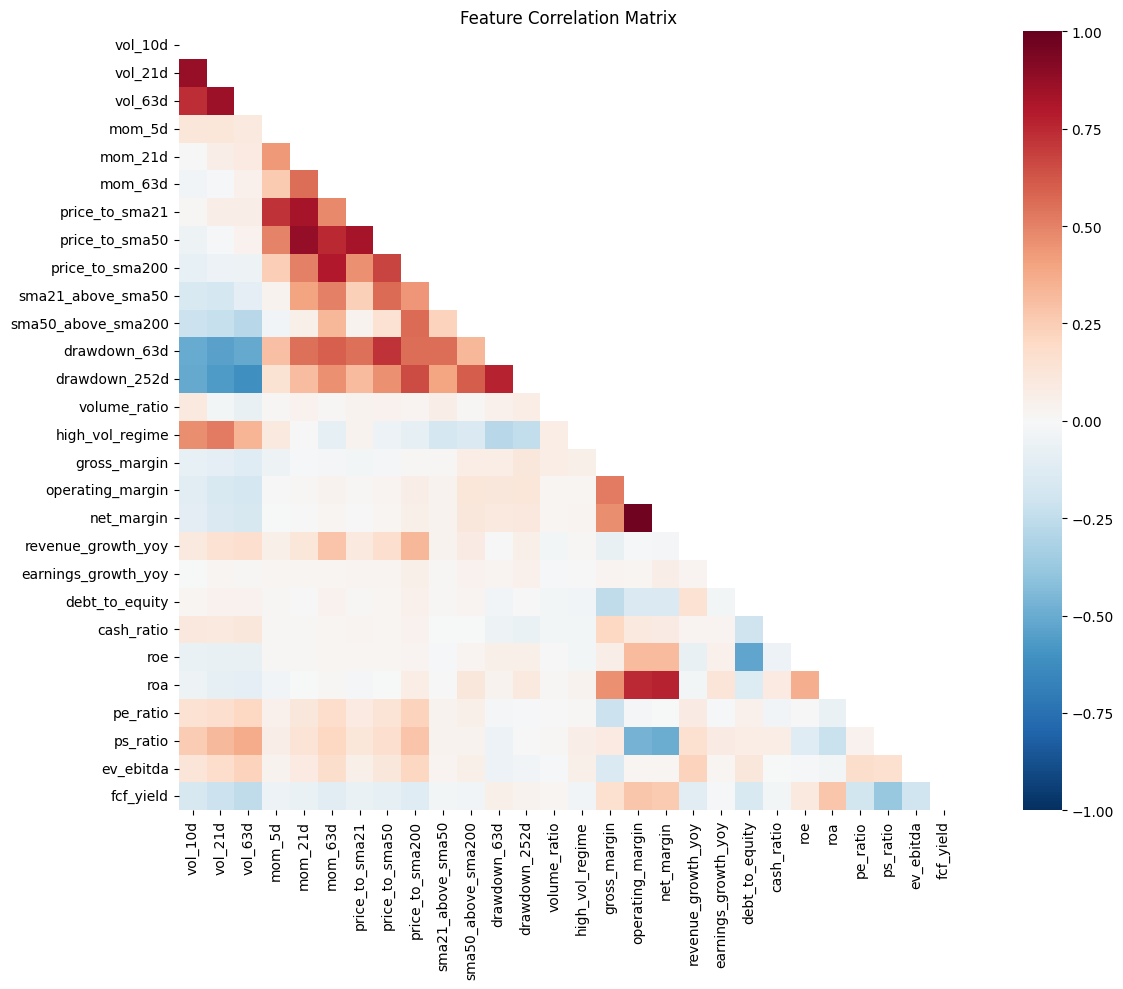

In [18]:
# Feature correlation matrix (top correlations)
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlations
corr = features[existing_features].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlations.png', dpi=150)
plt.show()

In [19]:
# Highly correlated pairs (>0.8)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'correlation': corr.iloc[i, j]
            })

if high_corr:
    print("Highly correlated pairs (|r| > 0.8):")
    print(pd.DataFrame(high_corr).sort_values('correlation', ascending=False))
else:
    print("No highly correlated pairs found.")

Highly correlated pairs (|r| > 0.8):
          feature_1        feature_2  correlation
6  operating_margin       net_margin     0.972219
3           mom_21d   price_to_sma50     0.877645
0           vol_10d          vol_21d     0.867354
1           vol_21d          vol_63d     0.853131
2           mom_21d   price_to_sma21     0.835180
5    price_to_sma21   price_to_sma50     0.829828
4           mom_63d  price_to_sma200     0.803310


## 8. Save Features

In [20]:
# Save features
features.to_parquet(OUTPUT_DIR / 'features.parquet', index=False)
print(f"Saved: {OUTPUT_DIR / 'features.parquet'}")

# Save feature summary
feature_stats.to_csv(OUTPUT_DIR / 'feature_summary.csv')
print(f"Saved: {OUTPUT_DIR / 'feature_summary.csv'}")

# Final summary
print(f"\n{'='*60}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*60}")
print(f"Tickers: {features['symbol'].nunique()} ({', '.join(UNIVERSE)})")
print(f"Date range: {features['decision_date'].min()} to {features['decision_date'].max()}")
print(f"Total observations: {len(features)}")
print(f"Features: {len(existing_features)}")
print(f"  - Technical: {len([f for f in technical_features if f in existing_features])}")
print(f"  - Fundamental: {len([f for f in fundamental_features if f in existing_features])}")
print(f"  - Valuation: {len([f for f in valuation_features if f in existing_features])}")

Saved: ../data/processed/features.parquet
Saved: ../data/processed/feature_summary.csv

FEATURE ENGINEERING COMPLETE
Tickers: 10 (AAPL, AMZN, AVGO, GOOG, GOOGL, META, MSFT, NVDA, TSLA, WMT)
Date range: 2001-01-31 00:00:00 to 2025-12-31 00:00:00
Total observations: 2447
Features: 28
  - Technical: 15
  - Fundamental: 9
  - Valuation: 4


## 9. Feature Descriptions (for Report)

In [21]:
feature_descriptions = {
    # Technical
    'vol_10d': '10-day realized volatility (annualized)',
    'vol_21d': '21-day realized volatility (annualized)',
    'vol_63d': '63-day realized volatility (annualized)',
    'mom_5d': '5-day price momentum (return)',
    'mom_21d': '21-day price momentum (return)',
    'mom_63d': '63-day price momentum (return)',
    'price_to_sma21': 'Price relative to 21-day SMA',
    'price_to_sma50': 'Price relative to 50-day SMA',
    'price_to_sma200': 'Price relative to 200-day SMA',
    'sma21_above_sma50': 'Short-term trend indicator (21 SMA > 50 SMA)',
    'sma50_above_sma200': 'Long-term trend indicator (50 SMA > 200 SMA)',
    'drawdown_63d': 'Drawdown from 63-day high',
    'drawdown_252d': 'Drawdown from 252-day high',
    'volume_ratio': 'Volume relative to 21-day average',
    'high_vol_regime': 'Binary: current vol > historical median',
    # Fundamental
    'gross_margin': 'Gross profit / Revenue',
    'operating_margin': 'Operating income / Revenue',
    'net_margin': 'Net income / Revenue',
    'revenue_growth_yoy': 'Year-over-year revenue growth',
    'earnings_growth_yoy': 'Year-over-year earnings growth',
    'debt_to_equity': 'Total debt / Shareholder equity',
    'cash_ratio': 'Cash / Total liabilities',
    'roe': 'Return on equity (Net income / Equity)',
    'roa': 'Return on assets (Net income / Assets)',
    # Valuation
    'pe_ratio': 'Price-to-earnings ratio (TTM)',
    'ps_ratio': 'Price-to-sales ratio (TTM)',
    'ev_ebitda': 'Enterprise value / EBITDA (TTM)',
    'fcf_yield': 'Free cash flow yield (FCF / Market cap)',
}

desc_df = pd.DataFrame([
    {'feature': k, 'description': v} 
    for k, v in feature_descriptions.items() 
    if k in existing_features
])
desc_df.to_csv(OUTPUT_DIR / 'feature_descriptions.csv', index=False)
print("Feature descriptions:")
desc_df

Feature descriptions:


,feature,description
0,vol_10d,10-day realized volatility (annualized)
1,vol_21d,21-day realized volatility (annualized)
2,vol_63d,63-day realized volatility (annualized)
3,mom_5d,5-day price momentum (return)
4,mom_21d,21-day price momentum (return)
5,mom_63d,63-day price momentum (return)
6,price_to_sma21,Price relative to 21-day SMA
7,price_to_sma50,Price relative to 50-day SMA
8,price_to_sma200,Price relative to 200-day SMA
9,sma21_above_sma50,Short-term trend indicator (21 SMA > 50 SMA)
